# MSBA Cost of Living Analysis After Graduation

**Student Submission Notebook**

**Question:** Estimate the expected cost of living in San Francisco, Los Angeles, and San Diego after completing an MSBA program.

**Answer:** This notebook estimates monthly and annual living costs in the three cities using editable assumptions for housing, food, transportation, utilities, healthcare, and miscellaneous spending. It also calculates both the minimum annual salary needed and a desired target salary using simple tax, savings, and lifestyle adjustment assumptions.


## Overview

This analysis is designed to be easy to update. All key assumptions are defined near the top of the notebook, so changing values such as rent, taxes, savings rate, or lifestyle adjustment will automatically update the tables and chart below.

The notebook follows a simple and transparent approach suitable for a class assignment:

- Estimate monthly costs by category for each city.
- Compute total monthly and annual living expenses.
- Estimate the minimum gross annual salary needed using an effective tax rate.
- Estimate a desired salary that adds savings and an extra discretionary lifestyle buffer.


In [1]:
# Import standard data analysis libraries
import pandas as pd
import matplotlib.pyplot as plt

# Display numeric outputs with two decimal places
pd.options.display.float_format = '{:,.2f}'.format


## Assumptions

The following assumptions are realistic placeholder values for a recent MSBA graduate living independently in each city. These can be edited and the notebook can be re-run to update all results.


In [ ]:
# -----------------------------
# Editable assumptions section
# -----------------------------

# Effective tax assumption used to convert after-tax needs into gross salary
effective_tax_rate = 0.27

# Savings goal as a share of gross salary for the desired salary estimate
savings_rate = 0.15

# Additional lifestyle buffer applied to annual expenses for the desired salary estimate
desired_lifestyle_adjustment = 0.12

# Monthly cost assumptions by city and spending category
city_costs = {
    'San Francisco': {
        'Housing': 2700,
        'Food': 750,
        'Transportation': 220,
        'Utilities': 240,
        'Healthcare': 280,
        'Miscellaneous': 500
    },
    'Los Angeles': {
        'Housing': 2500,
        'Food': 650,
        'Transportation': 300,
        'Utilities': 220,
        'Healthcare': 260,
        'Miscellaneous': 450
    },
    'San Diego': {
        'Housing': 2300,
        'Food': 620,
        'Transportation': 240,
        'Utilities': 210,
        'Healthcare': 250,
        'Miscellaneous': 425
    }
}

# Show the key editable assumptions in a compact table
assumptions_summary = pd.DataFrame({
    'Assumption': ['Effective tax rate', 'Savings rate', 'Desired lifestyle adjustment'],
    'Value': [effective_tax_rate, savings_rate, desired_lifestyle_adjustment]
})

assumptions_summary


,Assumption,Value
0,Effective tax rate,0.27
1,Savings rate,0.15
2,Desired lifestyle adjustment,0.12


## Monthly Cost Estimates by City

The table below organizes the estimated monthly spending by category for each city. This creates a clear comparison of how expected living costs differ across San Francisco, Los Angeles, and San Diego.


In [3]:
# Convert the dictionary of city assumptions into a DataFrame
monthly_cost_df = pd.DataFrame(city_costs).T

# Calculate total estimated monthly and annual costs
monthly_cost_df['Total Monthly Cost'] = monthly_cost_df.sum(axis=1)
monthly_cost_df['Total Annual Cost'] = monthly_cost_df['Total Monthly Cost'] * 12

# Display the organized monthly cost table
monthly_cost_df


,Housing,Food,Transportation,Utilities,Healthcare,Miscellaneous,Total Monthly Cost,Total Annual Cost
San Francisco,3200,750,220,240,280,500,5190,62280
Los Angeles,2500,650,300,220,260,450,4380,52560
San Diego,2300,620,240,210,250,425,4045,48540


## Salary Calculation Method

Two salary measures are estimated for each city:

- **Minimum annual salary needed:** the gross salary required to cover annual living expenses after accounting for an effective tax rate.
- **Desired salary:** a higher target salary that includes the same expenses plus a savings goal and a discretionary lifestyle buffer.

These estimates are intentionally simple so that the logic is transparent and easy to explain in a classroom setting.


In [4]:
# Create a copy of the cost table for salary calculations
salary_summary = monthly_cost_df[['Total Monthly Cost', 'Total Annual Cost']].copy()

# Calculation 1:
# Minimum gross salary needed to cover annual expenses after taxes
salary_summary['Minimum Annual Salary Needed'] = (
    salary_summary['Total Annual Cost'] / (1 - effective_tax_rate)
)

# Calculation 2:
# Desired salary includes an added lifestyle buffer and a savings target
salary_summary['Desired Annual Salary'] = (
    salary_summary['Total Annual Cost'] * (1 + desired_lifestyle_adjustment) / (1 - effective_tax_rate - savings_rate)
)

# Round values to improve readability in the final table
salary_summary = salary_summary.round(2)

salary_summary


,Total Monthly Cost,Total Annual Cost,Minimum Annual Salary Needed,Desired Annual Salary
San Francisco,5190,62280,"85,315.07","120,264.83"
Los Angeles,4380,52560,"72,000.00","101,495.17"
San Diego,4045,48540,"66,493.15","93,732.41"


## Interpretation

The salary estimates highlight how housing remains the largest driver of cost differences across cities. San Francisco has the highest expected living cost and therefore requires the highest estimated salary, while San Diego is the least expensive of the three in this comparison.

The desired salary is intentionally higher than the minimum salary because it includes both a savings goal and extra room for discretionary spending, which better reflects a more comfortable post-graduation lifestyle.


## Salary Comparison Plot

The chart below compares the minimum salary needed and the desired salary for each city.


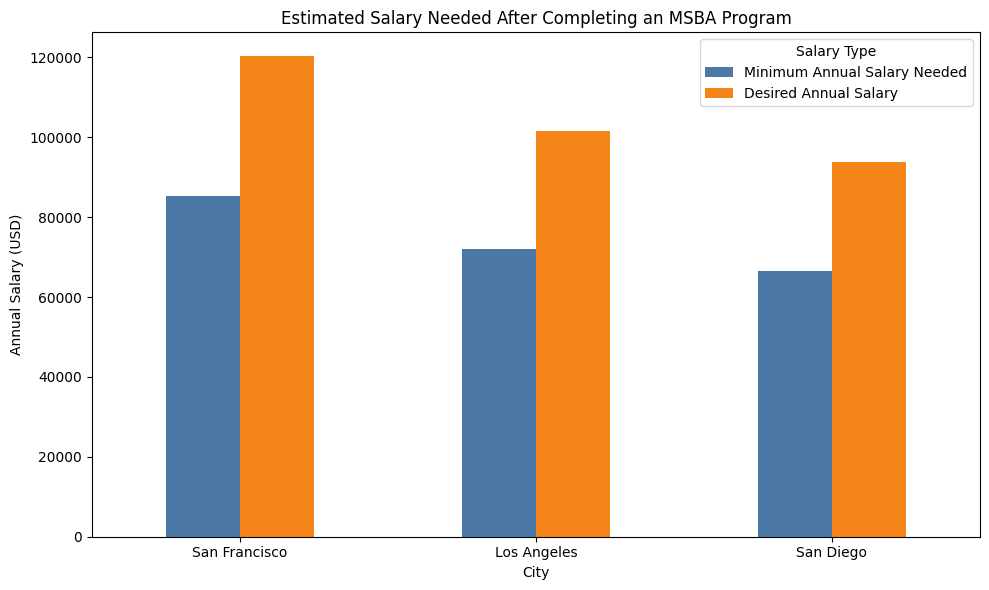

In [5]:
# Plot minimum salary versus desired salary for each city
plot_df = salary_summary[['Minimum Annual Salary Needed', 'Desired Annual Salary']]

ax = plot_df.plot(
    kind='bar',
    figsize=(10, 6),
    color=['#4C78A8', '#F58518']
)

ax.set_title('Estimated Salary Needed After Completing an MSBA Program')
ax.set_xlabel('City')
ax.set_ylabel('Annual Salary (USD)')
ax.tick_params(axis='x', rotation=0)
ax.legend(title='Salary Type')
plt.tight_layout()
plt.show()


## Conclusion

Based on the assumptions used in this notebook, San Francisco requires the highest post-MSBA salary to support an independent lifestyle, followed by Los Angeles and then San Diego. Because all assumptions are grouped near the top, this notebook can easily be adjusted to reflect a different apartment budget, commuting pattern, tax assumption, or savings goal.

This makes the notebook useful not only as a class assignment submission, but also as a practical personal planning tool for comparing future living options after graduation.
